# Import libraries and load the Wine dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import load_wine

In [3]:
#load the dataset
wine = load_wine()

In [4]:
#i turn the features into a table, usine real column names 
df = pd.DataFrame(wine.data, columns = wine.feature_names)

In [5]:
# I add the target column 
df["target"] = wine.target

In [6]:
#load the first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# Dataset summary

In [7]:
#Check the size of dataset
print("Dataset shape:", df.shape)

Dataset shape: (178, 14)


In [8]:
#count the features
print("Number of features:", len(wine.feature_names))

Number of features: 13


In [9]:
#check the wine class
print("Number of classes:", df["target"].nunique())

Number of classes: 3


In [10]:
print("Class names:", wine.target_names)

Class names: ['class_0' 'class_1' 'class_2']


In [11]:
# count how many rows belong to each class
print("\nClass distribution:")
print(df["target"].value_counts().sort_index())


Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


In [12]:
#check for missing values
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 0


In [13]:
#check the basic statistics
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Part 1 interpretation

In this part, I loaded the Wine dataset from Scikit-Learn and explored it. The dataset has 178 rows and 14 columns. Out of these, 13 columns are features, which are chemical measurements of the wine such as alcohol, malic acid, magnesium, and color intensity. The last column is the target, which tells me the class of each wine.

There are 3 classes in the dataset, named class_0, class_1, and class_2. Class 0 has 59 wines (about 33%), class 1 has 71 wines (about 40%), and class 2 has 48 wines (about 27%). This means the classes are not perfectly equal, but the difference is small, so the dataset is only slightly imbalanced. There are no missing values, so I do not need to clean the data before using it.

From the statistics, I noticed that the features are on very different scales. For example, alcohol ranges from 11.03 to 14.83 with an average of about 13.0, while proline ranges from 278 to 1680 with an average of about 747. Hue is much smaller, with an average of about 0.96. This is important to remember, because some models, like Logistic Regression, work better when the features are scaled to a similar range.

# Part 2: Sampling Techniques

In [14]:
#Simple Random Sampling
#I take 50 rows completely at random from the dataset
random_sample = df.sample(n=50, random_state=42) 


In [15]:
#I couunt how many wines of each class ended up in my random smaple
print ( "Simple random sample - class counts:")
print( random_sample["target"].value_counts().sort_index())
print ("\nSimple randome sample = class percentage;")
print((random_sample["target"].value_counts(normalize=True).sort_index() * 100).round(1))

Simple random sample - class counts:
target
0    17
1    20
2    13
Name: count, dtype: int64

Simple randome sample = class percentage;
target
0    34.0
1    40.0
2    26.0
Name: proportion, dtype: float64


In [16]:
#Stratified Sampling
# I take 50 rows, but this time I keep the same class percentages as the full dataset
# The "_" holds the leftover 128 rows, which I don't need
stratified_sample, _ = train_test_split(
    df,
    train_size=50,
    stratify=df["target"],
    random_state=42
)

In [17]:
# I count how many wines of each class ended up in my stratified sample
print("Stratified Sample - class counts:")
print(stratified_sample["target"].value_counts().sort_index())

# I show the same thing as percentages
print("\nStratified Sample - class percentages:")
print((stratified_sample["target"].value_counts(normalize=True).sort_index() * 100).round(1))

Stratified Sample - class counts:
target
0    17
1    20
2    13
Name: count, dtype: int64

Stratified Sample - class percentages:
target
0    34.0
1    40.0
2    26.0
Name: proportion, dtype: float64


Interpretation

In this part, I created two subsets of 50 samples from the Wine dataset using two different methods. The first method was Simple Random Sampling, where every row has an equal chance of being picked and the class is not considered at all. The second method was Stratified Sampling, where the data is first divided by class and then rows are picked from each class in the same proportion as the full dataset.

Both of my samples gave the same result. Each one had 17 wines from class 0, 20 from class 1, and 13 from class 2. In percentages, this is 34%, 40%, and 26%. The original dataset is about 33%, 40%, and 27%, so both samples are very close to the full dataset.

Even though the results are the same, the reason behind them is different. The stratified sample matches the original class mix on purpose, because the stratify option forces it to keep the same proportions. The simple random sample matched only by chance. With random_state=42, the random pick happened to land on the same class counts. If I used a different seed, the simple random sample could give different counts, and some classes could be over-represented or under-represented. The stratified sample would stay the same with any seed.

This taught me that simple random sampling can sometimes look representative by luck, but it is not guaranteed. Stratified sampling is more reliable, especially when the dataset is small or when one class is rare, because it makes sure every class is represented fairly.

I also learned that stratified does not mean balanced. Stratified sampling copies the original class mix, so if the original data is a little uneven, the sample is uneven in the same way. Making all classes equal is a different task, which I will do with SMOTE in the next part.

In [18]:
# I calculate the class percentages for the full dataset and for both samples
original_pct = df["target"].value_counts(normalize=True).sort_index() * 100
random_pct = random_sample["target"].value_counts(normalize=True).sort_index() * 100
stratified_pct = stratified_sample["target"].value_counts(normalize=True).sort_index() * 100

In [19]:
# I put all three side by side in one small table
compare = pd.DataFrame({
    "Original (178)": original_pct,
    "Simple Random (50)": random_pct,
    "Stratified (50)": stratified_pct
}).round(1)

In [20]:
# I show the table of numbers
print(compare)

        Original (178)  Simple Random (50)  Stratified (50)
target                                                     
0                 33.1                34.0             34.0
1                 39.9                40.0             40.0
2                 27.0                26.0             26.0


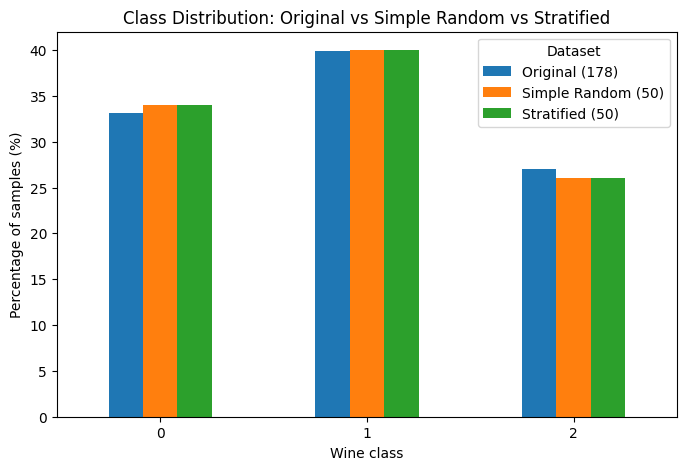

In [21]:
# I draw a grouped bar chart so I can compare the three visually
compare.plot(kind="bar", figsize=(8, 5))
plt.title("Class Distribution: Original vs Simple Random vs Stratified")
plt.xlabel("Wine class")
plt.ylabel("Percentage of samples (%)")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.show()

Interpretation

To compare the samples visually, I created a small table with the class percentages of the original dataset, the simple random sample, and the stratified sample. Then I used a grouped bar chart to show the three side by side for each wine class. I used percentages instead of counts because the original dataset has 178 rows and the samples have only 50, so percentages make the comparison fair.

The original dataset has 33.1% class 0, 39.9% class 1, and 27.0% class 2. Both of my samples have 34.0%, 40.0%, and 26.0%. In the chart, the bars for all three are almost the same height for every class, which shows that both samples represent the original dataset well. The stratified sample keeps this class mix by design, while the simple random sample matched it by chance in this case.

# Part 3: Handle Class Imbalance

In [22]:
#Create an imbalanced version of the dataset
# I separate class 0 from the other two classes
class_0 = df[df["target"] == 0]
other_classes = df[df["target"] != 0]

# I keep only 15 of the 59 class 0 wines, to make class 0 rare on purpose
class_0_small = class_0.sample(n=15, random_state=42)

# I join the 15 class 0 wines back together with the other classes
df_imbalanced = pd.concat([other_classes, class_0_small])


In [23]:
# I compare the class counts before and after
print("Original class counts:")
print(df["target"].value_counts().sort_index())

print("\nImbalanced class counts:")
print(df_imbalanced["target"].value_counts().sort_index())

# I show the new class percentages
print("\nImbalanced class percentages:")
print((df_imbalanced["target"].value_counts(normalize=True).sort_index() * 100).round(1))

print("\nTotal rows now:", len(df_imbalanced))

Original class counts:
target
0    59
1    71
2    48
Name: count, dtype: int64

Imbalanced class counts:
target
0    15
1    71
2    48
Name: count, dtype: int64

Imbalanced class percentages:
target
0    11.2
1    53.0
2    35.8
Name: proportion, dtype: float64

Total rows now: 134


Interpretation

In this step, I created an imbalanced version of the Wine dataset on purpose. The original dataset is only slightly uneven, with 59, 71, and 48 wines in the three classes, so there was no real imbalance problem to fix. To create one, I reduced class 0 from 59 wines to only 15, and I kept classes 1 and 2 the same.

I chose this approach for three reasons. First, reducing one class is a simple way to copy what happens in real life, where one group is often rare, like fraud cases or customers who convert. Second, I picked the 15 wines randomly instead of taking the first 15 rows, so the remaining class 0 wines are still a fair mix and not biased by the order of the data. Third, I saved the result in a new table called df_imbalanced and left the original df unchanged, because I need the original dataset again in the later parts.

After this change, the dataset has 134 rows. Class 0 is now only about 11% of the data, while class 1 is about 53% and class 2 is about 36%. This makes class 0 a clear minority class, which lets me test whether SMOTE can fix the imbalance in the next steps.

In [24]:
#Split into training and test sets
# I separate the features (X) from the target (y)
X = df_imbalanced.drop(columns="target")
y = df_imbalanced["target"]

In [25]:
# I split the data: 70% for training and 30% for testing
# stratify=y keeps the same class mix in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [26]:
# I check the size of each part
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

# I check the class counts in each part
print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nTest class counts:")
print(y_test.value_counts().sort_index())

Training rows: 93
Test rows: 41

Training class counts:
target
0    11
1    49
2    33
Name: count, dtype: int64

Test class counts:
target
0     4
1    22
2    15
Name: count, dtype: int64


In this step, I separated the features (X) from the target (y) and split the imbalanced dataset into a training set and a test set. I used 70% of the data for training and 30% for testing, which gave me 93 training rows and 41 test rows.

I used stratify so that both parts keep the same class mix. The training set has 11, 49, and 33 wines for classes 0, 1, and 2, and the test set has 4, 22, and 15. Class 0 is still the rare class in both parts, with only 11 wines for training and 4 for testing.

I split the data before applying SMOTE on purpose. This keeps the test set made of real wines only, so my results will be honest. SMOTE will be applied only to the training set in the next step.

In [27]:
#%pip install imbalanced-learn

In [28]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [29]:
# I create the SMOTE tool
smote = SMOTE(random_state=42)

In [30]:
# I apply SMOTE to the training data only
# It creates new synthetic wines for the smaller classes until every class matches the biggest one
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [31]:
# I compare the class counts before and after SMOTE
print("Training class counts BEFORE SMOTE:")
print(y_train.value_counts().sort_index())

print("\nTraining class counts AFTER SMOTE:")
print(y_train_smote.value_counts().sort_index())

# I check how many rows were added
print("\nTraining rows before:", len(X_train))
print("Training rows after:", len(X_train_smote))
print("Synthetic rows added:", len(X_train_smote) - len(X_train))

Training class counts BEFORE SMOTE:
target
0    11
1    49
2    33
Name: count, dtype: int64

Training class counts AFTER SMOTE:
target
0    49
1    49
2    49
Name: count, dtype: int64

Training rows before: 93
Training rows after: 147
Synthetic rows added: 54


Interpretation

In this step, I applied SMOTE to the training set to fix the class imbalance. Before SMOTE, the training set had 11, 49, and 33 wines for classes 0, 1, and 2. After SMOTE, every class has 49 wines, so the training set is now fully balanced.

SMOTE added 54 synthetic wines in total, which increased the training set from 93 rows to 147 rows. It created 38 new wines for class 0 and 16 new wines for class 2, so that both match class 1, which is the biggest class. These new wines are not copies. SMOTE creates each one between a real wine and one of its nearest neighbours from the same class, so the new data stays similar to the real data.

I applied SMOTE only to the training set. The test set still has only real wines, so I can compare the two models fairly in the next step.

In [32]:
# Train Random Forest on both datasets and compare
# Model 1: I train a Random Forest on the IMBALANCED training data
rf_imbalanced = RandomForestClassifier(random_state=42)
rf_imbalanced.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
# Model 2: I train a Random Forest on the BALANCED (SMOTE) training data
rf_balanced = RandomForestClassifier(random_state=42)
rf_balanced.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
# I use both models to predict the same real test set
pred_imbalanced = rf_imbalanced.predict(X_test)
pred_balanced = rf_balanced.predict(X_test)

In [35]:
# I print Precision, Recall, and F1-Score for each model
print("Model 1: trained on IMBALANCED data")
print(classification_report(y_test, pred_imbalanced))

print("Model 2: trained on BALANCED (SMOTE) data")
print(classification_report(y_test, pred_balanced))


Model 1: trained on IMBALANCED data
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.95      0.86      0.90        22
           2       0.88      1.00      0.94        15

    accuracy                           0.90        41
   macro avg       0.86      0.87      0.86        41
weighted avg       0.91      0.90      0.90        41

Model 2: trained on BALANCED (SMOTE) data
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.86      0.93        22
           2       0.88      1.00      0.94        15

    accuracy                           0.93        41
   macro avg       0.89      0.95      0.92        41
weighted avg       0.94      0.93      0.93        41



Interpretation

In this step, I trained two Random Forest models and tested both on the same 41 real test wines. The first model learned from the imbalanced training data, and the second model learned from the training data balanced with SMOTE. The support column shows 4, 22, and 15 test wines for classes 0, 1, and 2, which comes from the stratified split.

For the model trained on imbalanced data, class 0 had a precision of 0.75, a recall of 0.75, and an F1-Score of 0.75. The recall of 0.75 means the model found only 3 of the 4 real class 0 wines and missed 1. The precision of 0.75 means that when the model predicted class 0, it was right 3 times out of 4. This shows the model struggled with the rare class, because it had only 11 class 0 wines to learn from.

For the model trained on balanced data, class 0 had a precision of 0.80, a recall of 1.00, and an F1-Score of 0.89. The recall of 1.00 means the model found all 4 real class 0 wines and missed none. The precision of 0.80 means it predicted class 0 five times and was right 4 times, so there was 1 false alarm. The F1-Score for class 0 improved from 0.75 to 0.89.

The other classes stayed about the same or improved a little. Class 1 precision went from 0.95 to 1.00, and class 2 did not change. Overall accuracy improved from 0.90 to 0.93, and the macro average F1-Score improved from 0.86 to 0.92. I focused on the macro average because it treats every class equally, which is fairer when one class is rare.

Overall, SMOTE helped the model learn the rare class better, mainly by improving recall. One limit is that my test set has only 4 class 0 wines, so a single wine changes the score by 25 points. The improvement is real in my results, but I would need a larger dataset to be more confident about it.

# Part 4: Labeling Data Using Heuristics

In [36]:
#Look at alcohol by class to choose the thresholds
# I check the alcohol level for each real wine class
alcohol_by_class = df.groupby("target")["alcohol"].agg(["mean", "min", "max"]).round(2)
print(alcohol_by_class)

         mean    min    max
target                     
0       13.74  12.85  14.83
1       12.28  11.03  13.86
2       13.15  12.20  14.34


Interpretation

Before writing my rule, I checked the alcohol level for each real wine class. Class 0 has the highest alcohol, with an average of 13.74. Class 1 has the lowest, with an average of 12.28. Class 2 is in the middle, with an average of 13.15. This gave me an idea for a simple rule: high alcohol means class 0, low alcohol means class 1, and anything in between means class 2. I also noticed that the ranges overlap. For example, class 1 goes up to 13.86 and class 2 goes down to 12.20, so alcohol alone cannot separate the classes perfectly.

In [37]:
#Create the heuristic rule and apply it
# I write my rule: it labels a wine using only its alcohol value
def label_by_alcohol(alcohol):
    if alcohol >= 13.5:
        return 0      
    elif alcohol < 12.5:
        return 1      
    else:
        return 2      

In [38]:
# I make a copy of the dataset so my original df stays clean for the later parts
df_labeled = df.copy()

In [39]:
# I apply the rule to every wine and save the result in a new column
df_labeled["heuristic_label"] = df_labeled["alcohol"].apply(label_by_alcohol)

In [40]:
# I show the first 10 rows to compare the real class with my rule's label
print(df_labeled[["alcohol", "target", "heuristic_label"]].head(10))

   alcohol  target  heuristic_label
0    14.23       0                0
1    13.20       0                2
2    13.16       0                2
3    14.37       0                0
4    13.24       0                2
5    14.20       0                0
6    14.39       0                0
7    14.06       0                0
8    14.83       0                0
9    13.86       0                0


In [41]:
# I count how many wines my rule put in each class
print("\nHeuristic label counts:")
print(df_labeled["heuristic_label"].value_counts().sort_index())


Heuristic label counts:
heuristic_label
0    57
1    57
2    64
Name: count, dtype: int64


In [42]:
# I check how often my rule agrees with the real class
matches = (df_labeled["heuristic_label"] == df_labeled["target"]).sum()
print("\nCorrect labels:", matches, "out of", len(df_labeled))
print("Agreement:", round(matches / len(df_labeled) * 100, 1), "%")



Correct labels: 124 out of 178
Agreement: 69.7 %


In [43]:
# I build a table that shows where my rule was right and where it was wrong
print("\nReal class (rows) vs heuristic label (columns):")
print(pd.crosstab(df_labeled["target"], df_labeled["heuristic_label"]))


Real class (rows) vs heuristic label (columns):
heuristic_label   0   1   2
target                     
0                42   0  17
1                 2  52  17
2                13   5  30


Interpretation

In this part, I created a simple rule to label each wine using only its alcohol value. If the alcohol is 13.5 or higher, my rule labels the wine as class 0. If it is below 12.5, the rule labels it as class 1. Everything in between is labeled as class 2. I applied this rule to all 178 wines and saved the result in a new column called heuristic_label. I used a copy of the dataset, so my original data stays clean for the later parts.

My rule labeled 57 wines as class 0, 57 as class 1, and 64 as class 2. When I compared these labels with the real classes, 124 out of 178 were correct, which is an agreement of 69.7%. This means about 30% of the labels, or 54 wines, are wrong. I can already see this in the first 10 rows. All 10 wines are really class 0, but three of them, with alcohol values of 13.20, 13.16, and 13.24, were labeled as class 2 because they fall below my 13.5 cut-off.

The comparison table shows where the mistakes happened. For class 0, the rule got 42 of 59 wines right and labeled 17 as class 2. For class 1, it got 52 of 71 right, but labeled 17 as class 2 and 2 as class 0. Class 2 was the hardest, with only 30 of 48 correct, because 13 were labeled as class 0 and 5 as class 1. Class 2 sits in the middle of the alcohol range, so it overlaps with both of the other classes.

This shows the main issues with using heuristics for labeling. First, the labels are noisy. A model trained on these labels would learn from about 30% wrong answers. Second, the rule uses only one feature and ignores the other 12, so it misses information that could separate the classes better. Third, the cut-off points of 13.5 and 12.5 are my own choices, and a small change in them would change many labels. Fourth, the rule may not work on new data, because wines from a different region or year could have different alcohol levels. Finally, if I trained a model on these labels and also gave it the alcohol column, the model would only learn my rule back, which is a form of data leakage.

Overall, heuristic labeling is fast and cheap, and it is useful when real labels are not available. However, the labels are not fully reliable, so they should be checked against a small set of real labels and improved by combining several rules, not just one.

# Part 5: Evaluate Model Performance (ROC Curve and AUC)

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [45]:
# I use the ORIGINAL dataset this time
X_orig = df.drop(columns="target")
y_orig = df["target"]

In [46]:
# I split the data: 70% for training and 30% for testing
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y_orig,
    test_size=0.3,
    stratify=y_orig,
    random_state=42
)

In [47]:
# I train the Decision Tree on the training data
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_o, y_train_o)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [48]:
# I check the size of each part and the accuracy on the test set
print("Training rows:", len(X_train_o))
print("Test rows:", len(X_test_o))
print("Test class counts:", y_test_o.value_counts().sort_index().tolist())

dt_predictions = dt_model.predict(X_test_o)
print("\nTest accuracy:", round(accuracy_score(y_test_o, dt_predictions), 3))

Training rows: 124
Test rows: 54
Test class counts: [18, 21, 15]

Test accuracy: 0.963


Interpretation

In this step, I trained a Decision Tree Classifier on the original Wine dataset with all 178 wines. I split the data into 124 training rows and 54 test rows, and I used stratify so the test set keeps the same class mix, with 18, 21, and 15 wines for classes 0, 1, and 2. The model reached a test accuracy of 0.963, which means it predicted 52 of the 54 test wines correctly.

In [50]:
#Plot the ROC curve and calculate the AUC
# I get the probability the model gives to each class, for every test wine
y_score = dt_model.predict_proba(X_test_o)

In [51]:
# I turn the real classes into 3 yes/no columns (one-vs-rest)
y_test_bin = label_binarize(y_test_o, classes=[0, 1, 2])

AUC for class 0: 0.972
AUC for class 1: 0.970
AUC for class 2: 0.967


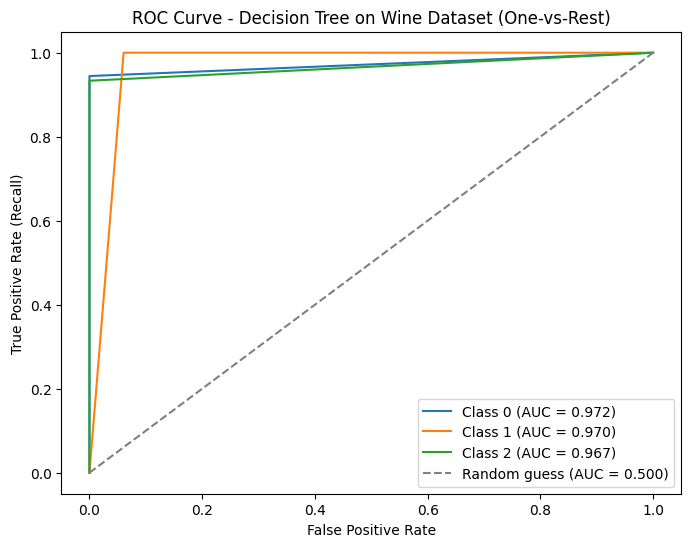

In [58]:
# I draw one ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    class_auc = auc(fpr, tpr)
    print(f"AUC for class {i}: {class_auc:.3f}")
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {class_auc:.3f})")

# I add a dashed diagonal line that shows what random guessing looks like
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.500)")

# I add the labels and show the chart
plt.title("ROC Curve - Decision Tree on Wine Dataset (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(loc="lower right")
plt.show()

In [59]:
# I calculate one overall AUC score, averaged across the 3 classes
overall_auc = roc_auc_score(y_test_o, y_score, multi_class="ovr")
print(f"\nOverall AUC (macro average): {overall_auc:.3f}")


Overall AUC (macro average): 0.970


Interpretation

In this step, I evaluated my Decision Tree using the ROC Curve and the AUC score. A ROC curve normally works for a yes or no problem, but the Wine dataset has 3 classes. To handle this, I used the one-vs-rest method, which draws one curve for each class by asking "is this wine this class, or not?"

The AUC score was 0.972 for class 0, 0.970 for class 1, and 0.967 for class 2. The overall AUC, averaged across the three classes, was 0.970. AUC ranges from 0.5, which means random guessing, to 1.0, which means perfect separation. A score of 0.970 means my model is very good at telling the three wine classes apart.

In the chart, all three curves rise quickly toward the top-left corner and stay far above the dashed diagonal line, which shows random guessing. This confirms the model performs much better than chance. The curves also show the small mistakes the model made. For class 0, the curve reaches about 0.94 on the True Positive Rate with no false positives, which means the model found 17 of the 18 real class 0 wines and never wrongly called another wine class 0. For class 2, it found 14 of the 15 real wines, also with no false positives. For class 1, the model found all 21 real wines, but the curve bends slightly to the right, because it wrongly labeled 2 other wines as class 1.

I also noticed that the curves look like sharp angles with only one corner, not smooth curves. This happens because a fully grown Decision Tree gives a probability of only 0 or 1 for each wine. It is completely sure about every prediction, so there is only one cut-off point to test. A model that gives probabilities in between, like Logistic Regression or Random Forest, would produce a smoother curve with more points.

Overall, the ROC curve and AUC tell me that the Decision Tree separates the wine classes very well, with only 2 mistakes out of 54 test wines. One limit is that my test set is small, so these scores could change with a different split. Also, because the tree is fully grown and very confident, it may be overfitting the training data, so I would test it with cross-validation before trusting it on new wines.

# Part 6: Data Augmentation

In [62]:
# Scale the data and create the augmented training set
# I scale the features because Logistic Regression works better when features are on a similar scale
# I fit the scaler on the training data only, then apply it to both parts
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_o)
X_test_scaled = scaler.transform(X_test_o)

# I create small random noise, one value for every cell in the training data
rng = np.random.default_rng(42)
noise = rng.normal(loc=0, scale=0.1, size=X_train_scaled.shape)

# I make a noisy copy of the training data
X_train_noisy = X_train_scaled + noise

# I stack the original and the noisy copy together to get the augmented training set
X_train_aug = np.vstack([X_train_scaled, X_train_noisy])
y_train_aug = np.concatenate([y_train_o, y_train_o])

In [63]:
# I check the sizes
print("Original training rows:", X_train_scaled.shape[0])
print("Augmented training rows:", X_train_aug.shape[0])

# I compare one wine before and after adding noise (first 4 features)
print("\nFirst wine, original:", X_train_scaled[0][:4].round(3))
print("First wine, with noise:", X_train_noisy[0][:4].round(3))

Original training rows: 124
Augmented training rows: 248

First wine, original: [ 0.983 -0.528  0.174 -1.088]
First wine, with noise: [ 1.013 -0.632  0.249 -0.993]


Interpretation

In this step, I prepared the data for augmentation. First, I scaled the features with StandardScaler, because Logistic Regression works better when all features are on a similar scale. I fitted the scaler on the training data only and then applied it to the test data, so no information from the test set leaks into training.

Then I created a noisy copy of the training data by adding small random noise to every value. For example, the first wine's first four values changed from 0.983, -0.528, 0.174, and -1.088 to 1.013, -0.632, 0.249, and -0.993. Each value moved only a little, so the wine is still similar to the original and keeps the same class.

Finally, I stacked the original training data and the noisy copy together. This doubled my training set from 124 rows to 248 rows. I added noise only to the training data, so the test set still has only real wines.

In [65]:
#Train Logistic Regression on both datasets and compare
# Model 1: I train Logistic Regression on the ORIGINAL training data
lr_original = LogisticRegression(max_iter=1000, random_state=42)
lr_original.fit(X_train_scaled, y_train_o)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [67]:
# Model 2: I train Logistic Regression on the AUGMENTED training data
lr_augmented = LogisticRegression(max_iter=1000, random_state=42)
lr_augmented.fit(X_train_aug, y_train_aug)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [68]:
# I use both models to predict the same real test set
pred_original = lr_original.predict(X_test_scaled)
pred_augmented = lr_augmented.predict(X_test_scaled)

In [69]:
# I compare the accuracy of the two models
print("Accuracy - original data: ", round(accuracy_score(y_test_o, pred_original), 3))
print("Accuracy - augmented data:", round(accuracy_score(y_test_o, pred_augmented), 3))

# I print the full report for each model
print("\nModel 1: trained on ORIGINAL data")
print(classification_report(y_test_o, pred_original))

print("Model 2: trained on AUGMENTED data")
print(classification_report(y_test_o, pred_augmented))


Accuracy - original data:  0.981
Accuracy - augmented data: 0.981

Model 1: trained on ORIGINAL data
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Model 2: trained on AUGMENTED data
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



Interpretation

In this step, I trained two Logistic Regression models and tested both on the same 54 real test wines. The first model learned from the original training data with 124 rows. The second model learned from the augmented training data with 248 rows, which includes the original wines and a noisy copy of each one.

Both models gave exactly the same results. Each one reached an accuracy of 0.981, which means 53 of the 54 test wines were predicted correctly. The precision, recall, and F1-Score were also the same for every class. For class 0, precision was 0.95 and recall was 1.00. For class 1, precision was 1.00 and recall was 0.95. For class 2, all three scores were 1.00. Both models made the same single mistake: one class 1 wine was predicted as class 0.

In my case, data augmentation did not change the model's performance. I think there are three reasons for this. First, the model was already almost perfect on the original data, so there was very little room to improve. Second, the Wine classes are well separated after scaling, so Logistic Regression can find clear boundaries between them without extra data. Third, the noise I added was small, so the noisy wines stayed close to the original wines and did not teach the model anything new.

This does not mean data augmentation is useless. The identical result is still a useful finding, because it shows that adding noisy data did not harm the model, and that the model is stable. Augmentation usually helps more when the dataset is small, when the model is complex and overfits easily, or when the real-world data is messy, such as images or text. It can also make a model more robust to small measurement errors, which my clean test set does not measure. For a simple and clean dataset like Wine, the original data was already enough.